# Orbital tools

The ``galport.OrbitTools`` module is designed for analysing orbital datasets in the action-angle space. The orbits are derived either from high-resolution N-body simulations or from specific initial conditions integrated within a potential. Also, the module allows calculating frequencies using `naif` package and is connected with the module ``galport.OrbitClassifier`` classifies the orbits' set.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import galport
import agama

Load coordinates, velocities and actions for the set of orbits

In [2]:
xv_act = np.load('data/xv_act_0.npy')

t = np.arange(0, 600.125, 0.125)
xv = xv_act[:,:,0:6]
act = xv_act[:,:,6:9]

Find actions, angles and frequencies of the set of orbits if their coordinates are known.

In [3]:
%%time

# 100 orbits
OT = galport.OrbitTools(t=t, xv=xv, act=act)
data = OT.calculate_actions(secular=True, parallel=False)

CPU times: user 2.75 s, sys: 37.1 ms, total: 2.79 s
Wall time: 2.79 s


In [4]:
%%time
# Example of parallel calculations
# 100 orbits
OT = galport.OrbitTools(t=t, xv=xv, act=act)
data = OT.calculate_actions(secular=True, parallel=True, n_jobs=8)

CPU times: user 133 ms, sys: 95.1 ms, total: 228 ms
Wall time: 799 ms


In [5]:
t0 = 400
n_t = int(t0)*8

JR = data[:,n_t,0]
Jz = data[:,n_t,1]
Lz = data[:,n_t,2]

JR_sec = data[:,n_t,9]
Jz_sec = data[:,n_t,10]
Lz_sec = data[:,n_t,11]

kappa = data[:,n_t,6]
omegaz = data[:,n_t,7]
Omega = data[:,n_t,8]

kappa_sec = data[:,n_t,12]
omegaz_sec = data[:,n_t,13]
Omega_sec = data[:,n_t,14]

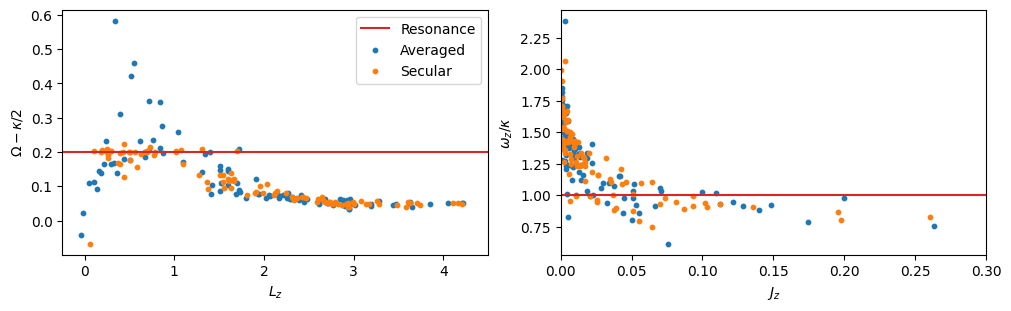

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10,3), constrained_layout=True)

axes[0].plot([-0.25, 4.5], [0.2,0.2], color='C3', label='Resonance')
axes[0].scatter(Lz, Omega - kappa/2, s=10, label='Averaged')
axes[0].scatter(Lz_sec, Omega_sec - kappa_sec/2, s=10, label='Secular')
axes[0].set_xlabel('$L_z$')
axes[0].set_ylabel('$\\Omega - \\kappa/2$')
axes[0].set_xlim(-0.25, 4.5)
axes[0].legend()

axes[1].plot([0., 0.3], [1,1], color='C3')
axes[1].scatter(Jz, omegaz/kappa, s=10)
axes[1].scatter(Jz_sec, omegaz_sec/kappa_sec, s=10)
axes[1].set_xlabel('$J_z$')
axes[1].set_ylabel('$\\omega_z/\\kappa$')
axes[1].set_xlim(0, 0.3)

plt.show()

Find actions, angles and frequencies of the set of orbits. In this case, the potential, the pattern speed and initial conditions ar known. Orbits are integrated forward and backward in time if ``reverse=True``.

In [7]:
%%time

pot_gal = agama.Potential(file='data/Pot_non_CylSpline_t400.ini')
pot_gal_sym = agama.Potential(file='data/Pot_axi_CylSpline_t400.ini')

Omega = np.load('data/omega_p.npy')[400*8]
phi = -np.load('data/phi_p.npy')[400*8]

# Rotate coordinates and velocities
xv0 = xv[:,400*8].copy()
x0 = xv0[:, 0].copy()
y0 = xv0[:, 1].copy()
vx0 = xv0[:, 3].copy()
vy0 = xv0[:, 4].copy()

xv0[:, 0] = x0*np.cos(phi) - y0*np.sin(phi)
xv0[:, 1] = x0*np.sin(phi) + y0*np.cos(phi)
xv0[:, 3] = vx0*np.cos(phi) - vy0*np.sin(phi)
xv0[:, 4] = vx0*np.sin(phi) + vy0*np.cos(phi)

OT_int = galport.OrbitTools(
    xv0=xv0,
    Tint=100,
    Nint=1000,
    potential=pot_gal,
    axisym_potential=pot_gal_sym,
    reverse=True,
    Omega=Omega
)

100 orbits complete (71.68 orbits/s)
100 orbits complete (68.73 orbits/s)


CPU times: user 48.4 s, sys: 46.1 ms, total: 48.5 s
Wall time: 3.45 s


In [8]:
%%time
data_int = OT_int.calculate_actions(secular=True, sidereal=True, parallel=True)

CPU times: user 126 ms, sys: 92.7 ms, total: 219 ms
Wall time: 323 ms


Comparison of actions for individual orbits obtained from N-body simulations and integration in a fixed potential.

## Comparison of the individual orbits

Actions for individual orbits obtained from N-body simulations and integration in a fixed potential.

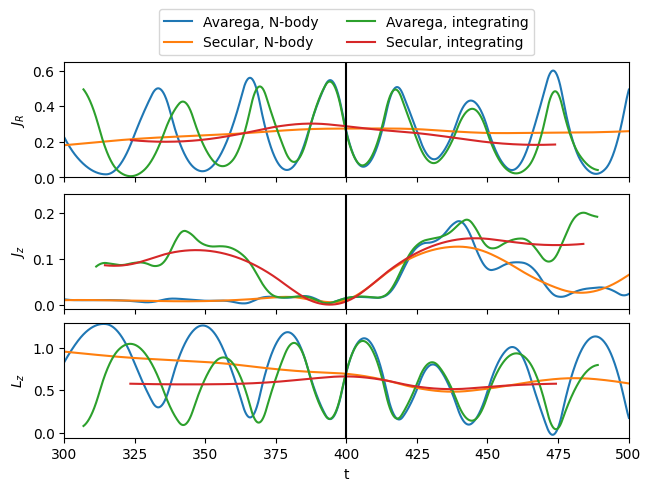

In [9]:
num = 7

# Actions

fig, axes = plt.subplots(3, constrained_layout=True, sharex=True)

# JR
JR = data[num,:,0]
JR_sec = data[num,:,9]
axes[0].plot(t, JR, label='Avarega, N-body')
axes[0].plot(t, JR_sec, label='Secular, N-body')
JR_int = data_int[num,:,0]
JR_sec_int = data_int[num,:,9]
axes[0].plot(OT_int.t + 400, JR_int, label='Avarega, integrating')
axes[0].plot(OT_int.t + 400, JR_sec_int, label='Secular, integrating')
axes[0].set_ylabel('$J_R$')
axes[0].set_xlim(300,500)
axes[0].plot([400,400], [-1,2], color='black')
axes[0].set_ylim(0, 1.2*np.nanmax(JR_int))
axes[0].legend(loc='lower center', bbox_to_anchor=(0.5, 1.0), ncol=2)

# Jz
Jz = data[num,:,1]
Jz_sec = data[num,:,10]
axes[1].plot(t, Jz)
axes[1].plot(t, Jz_sec)
Jz_int = data_int[num,:,1]
Jz_sec_int = data_int[num,:,10]
axes[1].plot(OT_int.t + 400, Jz_int)
axes[1].plot(OT_int.t + 400, Jz_sec_int)

axes[1].set_ylabel('$J_z$')
axes[1].set_xlim(300,500)
axes[1].plot([400,400], [-1,2], color='black')
axes[1].set_ylim(-0.01, 1.2*np.nanmax(Jz_int))

# Lz
Lz = data[num,:,2]
Lz_sec = data[num,:,11]
axes[2].plot(t, Lz)
axes[2].plot(t, Lz_sec)
Lz_int = data_int[7,:,2]
Lz_sec_int = data_int[7,:,11]
axes[2].plot(OT_int.t + 400, Lz_int)
axes[2].plot(OT_int.t + 400, Lz_sec_int)

axes[2].set_ylabel('$L_z$')
axes[2].set_xlabel('t')
axes[2].set_xlim(300,500)
axes[2].plot([400,400], [-1,2], color='black')
axes[2].set_ylim(np.nanmin(Lz_int)-0.1, 1.2*np.nanmax(Lz_int))

plt.show()

## Comparison of the set of orbits

Actions and frequencies at the middle of integretion time

In [10]:
n_t = (len(OT_int.t) // 2)

JR_int = data_int[:,n_t,0]
Jz_int = data_int[:,n_t,1]
Lz_int = data_int[:,n_t,2]

JR_sec_int = data_int[:,n_t,9]
Jz_sec_int = data_int[:,n_t,10]
Lz_sec_int = data_int[:,n_t,11]

kappa_int = data_int[:,n_t,6]
omegaz_int = data_int[:,n_t,7]
Omega_int = data_int[:,n_t,8]

kappa_sec_int = data_int[:,n_t,12]
omegaz_sec_int = data_int[:,n_t,13]
Omega_sec_int = data_int[:,n_t,14]

# Action and angle at the moment of time t=400

t = 400
n_t = int(t)*8

JR = data[:,n_t,0]
Jz = data[:,n_t,1]
Lz = data[:,n_t,2]

JR_sec = data[:,n_t,9]
Jz_sec = data[:,n_t,10]
Lz_sec = data[:,n_t,11]

kappa = data[:,n_t,6]
omegaz = data[:,n_t,7]
Omega = data[:,n_t,8]

kappa_sec = data[:,n_t,12]
omegaz_sec = data[:,n_t,13]
Omega_sec = data[:,n_t,14]

Comparison of actions for the set of orbits obtained from N-body simulations and integration in a fixed potential.

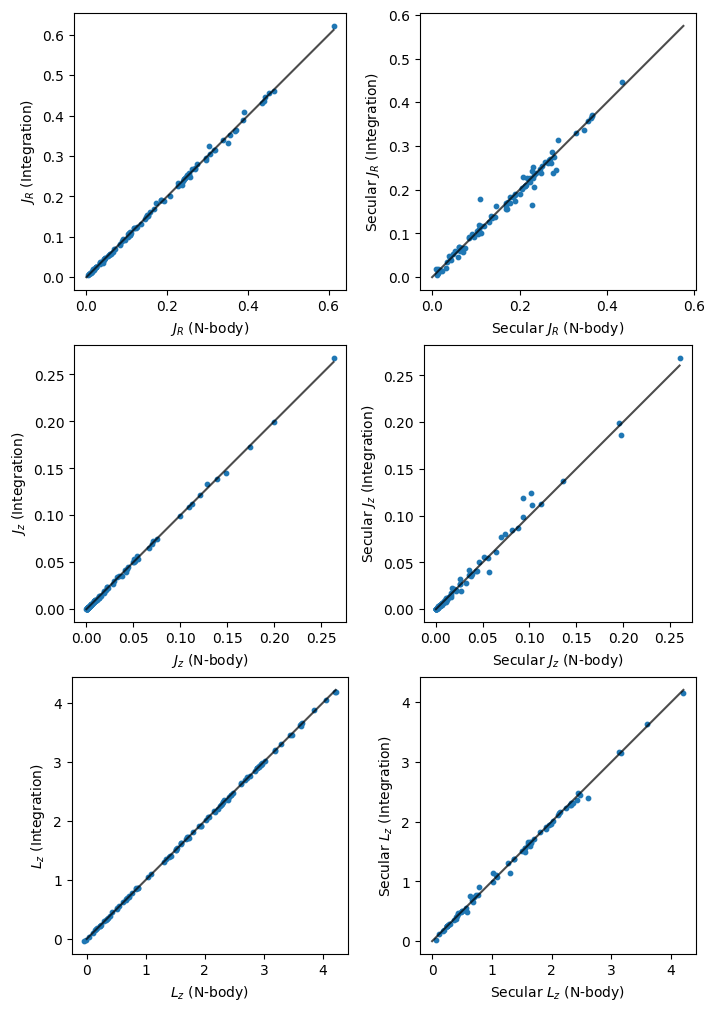

In [11]:
def plot_comparison(ax, x, y, x_label, y_label):
    ax.set_aspect('equal')
    ax.plot([0, np.nanmax(x)], [0.,np.nanmax(x)], color='black', alpha=0.7)
    ax.scatter(x, y, s=10)
    ax.set_xlabel(f'{x_label}')
    ax.set_ylabel(f'{y_label}')
    
fig, axes = plt.subplots(3, 2, figsize=(7,10), constrained_layout=True)

plot_comparison(axes[0,0], JR, JR_int, '$J_R$ (N-body)', '$J_R$ (Integration)')
plot_comparison(axes[0,1], JR_sec, JR_sec_int, 'Secular $J_R$ (N-body)', 'Secular $J_R$ (Integration)')
plot_comparison(axes[1,0], Jz, Jz_int, '$J_z$ (N-body)', '$J_z$ (Integration)')
plot_comparison(axes[1,1], Jz_sec, Jz_sec_int, 'Secular $J_z$ (N-body)', 'Secular $J_z$ (Integration)')
plot_comparison(axes[2,0], Lz, Lz_int, '$L_z$ (N-body)', '$L_z$ (Integration)')
plot_comparison(axes[2,1], Lz_sec, Lz_sec_int, 'Secular $L_z$ (N-body)', 'Secular $L_z$ (Integration)')
plt.show()

Comparison of frequencies for the set of orbits obtained from N-body simulations and integration in a fixed potential.

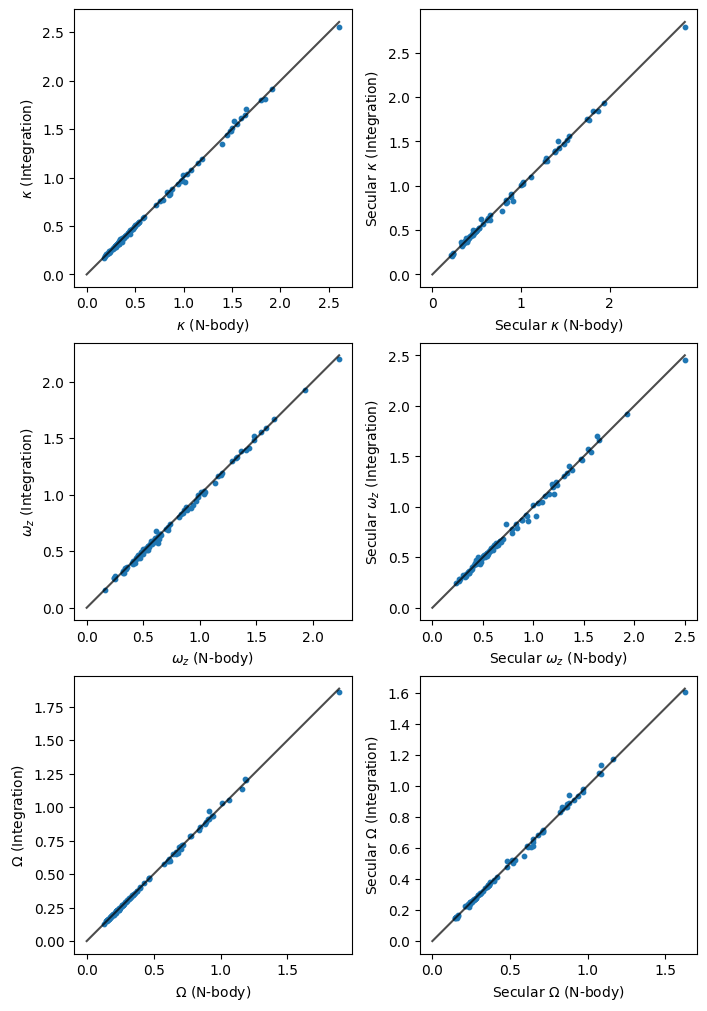

In [11]:
fig, axes = plt.subplots(3, 2, figsize=(7,10), constrained_layout=True)

plot_comparison(axes[0,0], kappa, kappa_int, '$\\kappa$ (N-body)', '$\\kappa$ (Integration)')
plot_comparison(axes[0,1], kappa_sec, kappa_sec_int, 'Secular $\\kappa$ (N-body)', 'Secular $\\kappa$ (Integration)')
plot_comparison(axes[1,0], omegaz, omegaz_int, '$\\omega_z$ (N-body)', '$\\omega_z$ (Integration)')
plot_comparison(axes[1,1], omegaz_sec, omegaz_sec_int, 'Secular $\\omega_z$ (N-body)', 'Secular $\\omega_z$ (Integration)')
plot_comparison(axes[2,0], Omega, Omega_int, '$\\Omega$ (N-body)', '$\\Omega$ (Integration)')
plot_comparison(axes[2,1], Omega_sec, Omega_sec_int, 'Secular $\\Omega$ (N-body)', 'Secular $\\Omega$ (Integration)')
plt.show()

## Comparison with frequency analysis naif

In [12]:
%%time
freq_naif = OT.naif_frequency(parallel=True)

kappa_naif = np.abs(freq_naif[:,0])
omegaz_naif = np.abs(freq_naif[:,1])
Omega_naif = freq_naif[:,2]

CPU times: user 56.7 ms, sys: 81.8 ms, total: 138 ms
Wall time: 330 ms


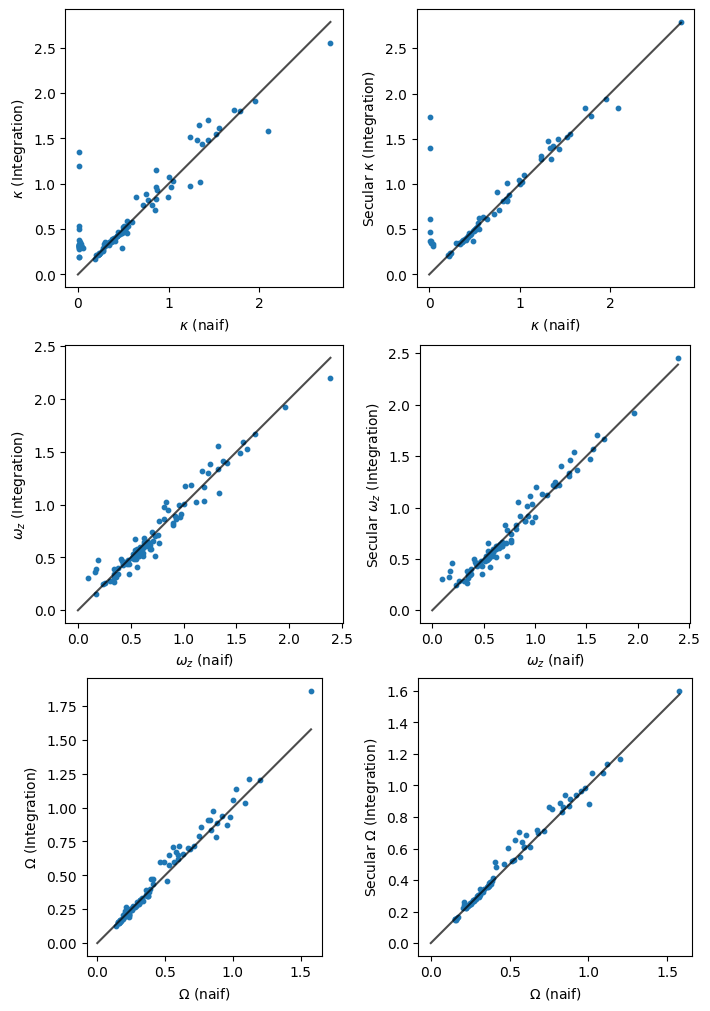

In [130]:
fig, axes = plt.subplots(3, 2, figsize=(7,10), constrained_layout=True)

plot_comparison(axes[0,0], kappa_naif, kappa_int, '$\\kappa$ (naif)', '$\\kappa$ (Integration)')
plot_comparison(axes[0,1], kappa_naif, kappa_sec_int, '$\\kappa$ (naif)', 'Secular $\\kappa$ (Integration)')
plot_comparison(axes[1,0], omegaz_naif, omegaz_int, '$\\omega_z$ (naif)', '$\\omega_z$ (Integration)')
plot_comparison(axes[1,1], omegaz_naif, omegaz_sec_int, '$\\omega_z$ (naif)', 'Secular $\\omega_z$ (Integration)')
plot_comparison(axes[2,0], Omega_naif, Omega_int, '$\\Omega$ (naif)', '$\\Omega$ (Integration)')
plot_comparison(axes[2,1], Omega_naif, Omega_sec_int, '$\\Omega$ (naif)', 'Secular $\\Omega$ (Integration)')
plt.show()